In this notebook we will generate a small fully connected neural network (FNN) for the classification on the MNIST dataset

In [1]:
#!pip install keras
#!pip install tensorflow

In [2]:
import keras
keras.__version__


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

'3.12.0'

Download data

In [3]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [4]:
train_images.ndim

3

In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
train_images.dtype

dtype('uint8')

In [7]:
len(train_labels)

60000

In [8]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [9]:
test_images.shape

(10000, 28, 28)

In [10]:
len(test_labels)

10000

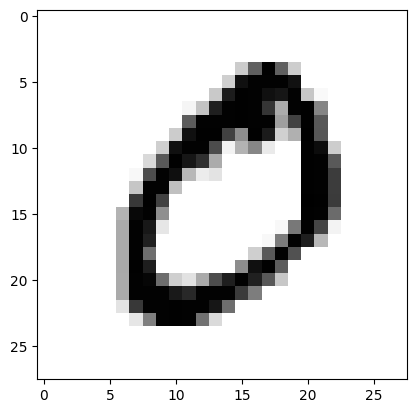

In [11]:
digit = train_images[1]

import matplotlib.pyplot as plt
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [12]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [13]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [14]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(200, activation='relu'))
network.add(layers.Dense(10, activation='softmax'))

C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Print a summary of the network
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       102,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 506,530 (1.93 MB)

 Trainable params: 506,530 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Set parameters for training the network
network.compile(optimizer='Adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


In [17]:
# Prepare the input data for NN
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [18]:
train_images.ndim

2

In [19]:
# Prepare labels for NN
from tensorflow.keras.utils import to_categorical

train_labels_cat = to_categorical(train_labels)
test_labels_cat = to_categorical(test_labels)

In [20]:
print(train_labels_cat)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [21]:
# Train the network to find the "optimal" parameters
network.fit(train_images, train_labels_cat, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9326 - loss: 0.2300
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9742 - loss: 0.0838
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9834 - loss: 0.0531
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0369
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9915 - loss: 0.0273




```

*   Why an epoch goes from 1 to 469?
*   What happens to the loss? and to tthe accuracy? is this expected?


```



In [22]:
# Let's check the prediction on some test images
test_digits = test_images[0:10]
predictions = network.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([6.6303038e-08, 6.2757255e-07, 1.7630449e-05, 8.5045700e-04,
       4.1781523e-10, 6.5398481e-08, 5.7777977e-11, 9.9911135e-01,
       2.2134477e-06, 1.7683880e-05], dtype=float32)

In [23]:
y_classes = predictions.argmax(axis=-1)
y_classes[0]

np.int64(7)

In [24]:
test_labels[0]

np.uint8(7)

In [27]:
# Let's check the accuracy on the test data
test_loss, test_acc = network.evaluate(test_images, test_labels_cat)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.9763 - loss: 0.0778


In [28]:
print('test_acc:', test_acc)

test_acc: 0.9763000011444092


In [29]:
y_pred = network.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step


In [30]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [31]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

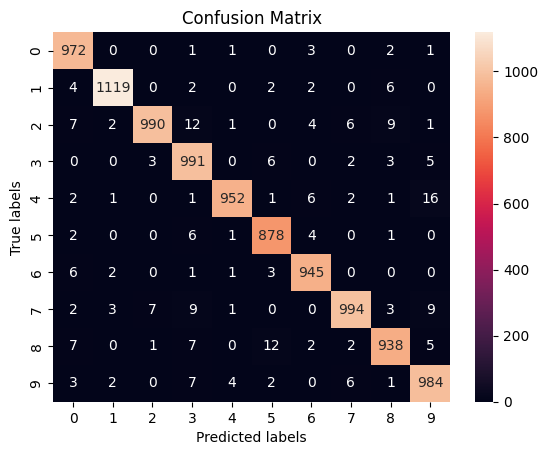

In [32]:
# Let's plot a confusion matrix
import sklearn.metrics as sklm
import seaborn as sns
import matplotlib.pyplot as plt

cm = sklm.confusion_matrix(test_labels, y_pred)

ax = plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');

**Extra notes **

Accesing the weights, bias parameters of the trained network

In [33]:
network.layers

[<Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [34]:
weights, bias = network.layers[0].get_weights()

In [35]:
weights.shape

(784, 512)

In [36]:
bias.shape

(512,)

In [37]:
weights_dense_1 = network.get_layer('dense').get_weights()

In [38]:
weights, bias = network.layers[2].get_weights()

In [39]:
weights

array([[-0.19282307, -0.04252726, -0.16251217, ..., -0.14273539,
         0.05069965,  0.16481803],
       [-0.18402682, -0.03785532, -0.12196641, ..., -0.0287119 ,
         0.15328886, -0.12729178],
       [ 0.11500054, -0.1131012 ,  0.17338447, ..., -0.06065999,
         0.20599812,  0.04106039],
       ...,
       [-0.14083754, -0.08234894, -0.18829775, ..., -0.14544524,
         0.04543157, -0.04766351],
       [ 0.10203592, -0.02274937,  0.11912033, ..., -0.21470454,
        -0.09028678, -0.18063709],
       [ 0.09799087, -0.07164887,  0.01121396, ...,  0.15321317,
         0.0517228 , -0.09583223]], shape=(200, 10), dtype=float32)

In [40]:
weights.shape

(200, 10)

Another way of defining the architecture

In [41]:
# Another way of defining the architecture
from tensorflow import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [42]:
# If we use original labels ("0", "3", "8", etc. instead of one-hot-encoded)
network.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Use train_labels instead of train_labels_cat
network.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9938 - loss: 0.0188
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9959 - loss: 0.0133
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9972 - loss: 0.0089
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9976 - loss: 0.0070
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - loss: 0.0047


In [43]:
# Another way of defining optimizer, loss, and metrics
network.compile(optimizer=keras.optimizers.RMSprop(),
                loss=keras.losses.CategoricalCrossentropy(),
                metrics=[keras.metrics.BinaryAccuracy()])

# Useful if using your own custom loss function or metric

Let's manually generate the Categorical Cross Entropy loss function

In [44]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np

# Define the custom categorical cross-entropy loss function
def custom_categorical_crossentropy(y_true, y_pred):
    # Clip predictions to prevent log(0)
    y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())

    # Compute categorical cross-entropy
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1)
    return tf.reduce_mean(loss)

In [45]:
# Compile the model using the custom loss function
network.compile(optimizer='adam',
                loss=custom_categorical_crossentropy,
                metrics=['accuracy'])

In [46]:
network.fit(train_images, train_labels_cat, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9941 - loss: 0.0176
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9961 - loss: 0.0118
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9951 - loss: 0.0149
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0088
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9973 - loss: 0.0086


In [47]:
test_loss, test_acc = network.evaluate(test_images, test_labels_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.9783 - loss: 0.1039
